<a href="https://colab.research.google.com/github/qrvdelossantos/CPE-311/blob/main/Midterm_Quiz_2_Data_Analysis_using_Pandas_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name:Rizaldy V. Delos Santos<br>
Course & Section:CPE 311-CPE22S3<br>
Date:03/05/2026<br>
Instructor:

**Overview**

Perform data analysis over the RT-IoT2022 Dataset using Pandas.

**Submission Requirements**



1.   Submit the PDF file of the data analysis using pandas for the RT-IoT2022 Dataset.
2.   Submit the link to your Python notebook through the comments for point of clarification.



**Procedure**

For this quiz, you must build an end-to-end data analysis notebook following the ETL pipeline.



1.   On a separate document, create a table with 3 columns. Column 1: Phase, Column 2: Activity, and Column 3: Code and Output.


*Phase will only have 3 major rows: Extract, Transform, Load<br>
*Activity will list down all the activities you performed per phase.<br>
*Code and output will correspond to the activity.<br>




2.   Extract the provided dataset using FLAT FILE. You get extra points for loading it through Kaggle API.<br>

import kagglehub<br>
#Download latest version<br>
path = kagglehub.dataset_download("supplejade/rt-iot2022real-time-internet-of-things")

print("Path to dataset files:", path)

3.   Transform the dataset. List down all activities included in the transformation.
4.   Show the transformed dataset.
5.   Load the dataset and perform statistical analysis and visualization. List down all activities included in the "load" phase.






In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [27]:
def extract_data_from_kaggle(dataset_name="supplejade/rt-iot2022real-time-internet-of-things", path="./kaggle_data"):
    print(f"--- Starting Data Extraction for: {dataset_name} ---")
    try:
        import kaggle
        from kaggle.api.kaggle_api_extended import KaggleApi
        api = KaggleApi()
        api.authenticate()

        if not os.path.exists(path):
            os.makedirs(path)
            print(f"Created directory: {path}")

        print("Downloading dataset using Kaggle API...")
        api.dataset_download_files(dataset_name, path=path, unzip=True)
        print("Dataset downloaded and unzipped successfully.")

        csv_file = None
        for dirname, _, filenames in os.walk(path):
            for filename in filenames:
                if filename.endswith('.csv') or filename.endswith('.CSV'):
                    csv_file = os.path.join(dirname, filename)
                    break
            if csv_file:
                break

        if csv_file:
            print(f"Path to dataset file: {csv_file}")
            return csv_file
        else:
            print("CSV file not found in the extracted directory.")
            return None

    except Exception as e:
        print(f"Error during Kaggle API extraction: {e}")
        print("Please ensure you have configured your Kaggle API credentials (kaggle.json).")
        return "./RT_IOT2022.csv"

In [28]:
csv_file_path = extract_data_from_kaggle()
if csv_file_path and os.path.exists(csv_file_path):
    print(f"\n--- Loading data into pandas DataFrame from {csv_file_path} ---")
    data = pd.read_csv(csv_file_path, low_memory=False)
    print("Data loaded successfully.")
    print(f"Original dataset shape: {data.shape}")
else:
    print("\nError: Dataset file not available for loading.")
    data = pd.DataFrame()

--- Starting Data Extraction for: supplejade/rt-iot2022real-time-internet-of-things ---
Error during Kaggle API extraction: Could not find kaggle.json. Make sure it's located in /root/.config/kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/
Please ensure you have configured your Kaggle API credentials (kaggle.json).

--- Loading data into pandas DataFrame from ./RT_IOT2022.csv ---
Data loaded successfully.
Original dataset shape: (123117, 85)


In [29]:
def transform_data(df):
  print("Starting Data Transformation")
  if df.empty:
    print("DataFrame is empty, skipping transformation.")
    return df
  print(f"Missing values before cleaning:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

  df = df.dropna()
  print("Handled missing values (dropped rows with NaNs).")

  initial_row_count = df.shape[0]
  df.drop_duplicates(inplace=True)
  print(f"Dropped{initial_row_count - df.shape[0]} duplicate rows.")

  df.replace([np.inf, -np.inf], np.nan, inplace=True)
  df.dropna(inplace=True)
  print("Replaced infinite values with NaN and dropped corresponding rows.")

  numeric_features = ['id.resp_p', 'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec']
  for col in numeric_features:
      if col in df.columns:
          df[col] = pd.to_numeric(df[col], errors='coerce')
  df.dropna(inplace=True)

  df['total_pkts'] = df['fwd_pkts_tot'] + df['bwd_pkts_tot']
  print("Engineered 'total_pkts' feature.")


  print(f"\nColumns after initial cleaning: {df.columns.tolist()}")
  label_col = 'Label'
  if label_col in df.columns:
      from sklearn.preprocessing import LabelEncoder
      le = LabelEncoder()
      df[label_col + '_encoded'] = le.fit_transform(df[label_col])
      print(f"Encoded target variable '{label_col}'. Mappings: {list(zip(le.classes_, le.transform(le.classes_)))}")
  else:
      print(f"Warning: Target label column '{label_col}' not found for encoding.")

  print(f"\nTransformed dataset shape: {df.shape}")
  print("--- Data Transformation Complete ---")
  return df


Column 'attack_type' not found.
Transformed Dataset Sample
   no  id.orig_p  id.resp_p proto service  flow_duration  fwd_pkts_tot  \
0   0      38667       1883   tcp    mqtt      32.011598             9   
1   1      51143       1883   tcp    mqtt      31.883584             9   
2   2      44761       1883   tcp    mqtt      32.124053             9   
3   3      60893       1883   tcp    mqtt      31.961063             9   
4   4      51087       1883   tcp    mqtt      31.902362             9   

   bwd_pkts_tot  fwd_data_pkts_tot  bwd_data_pkts_tot  ...  active.std  \
0             5                  3                  3  ...         0.0   
1             5                  3                  3  ...         0.0   
2             5                  3                  3  ...         0.0   
3             5                  3                  3  ...         0.0   
4             5                  3                  3  ...         0.0   

       idle.min      idle.max      idle.tot      id

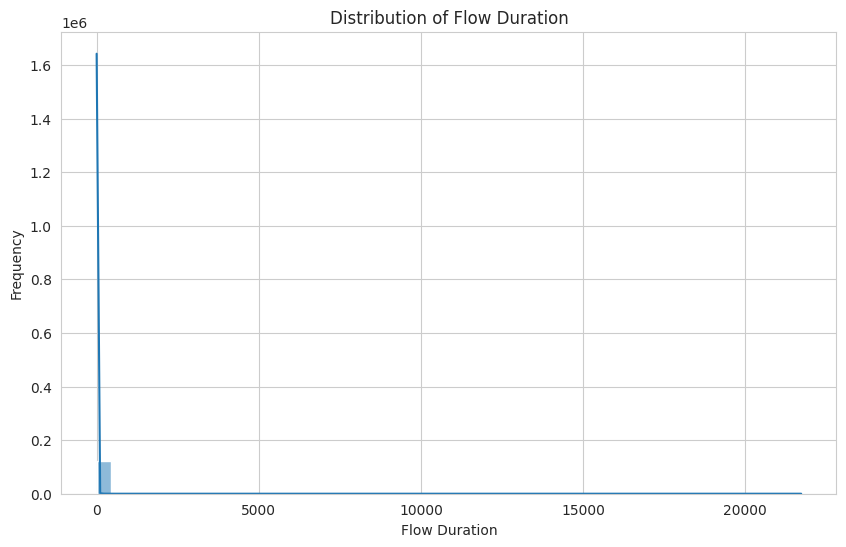

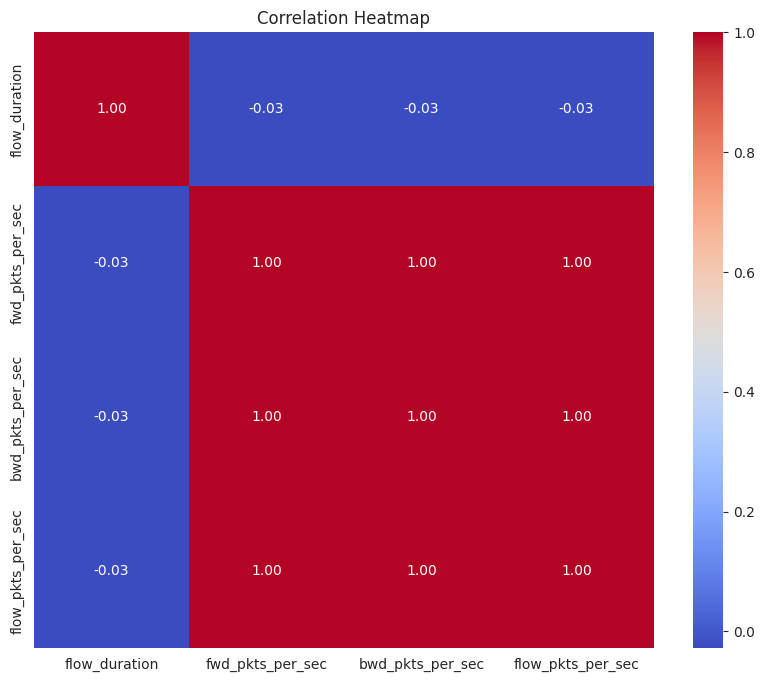

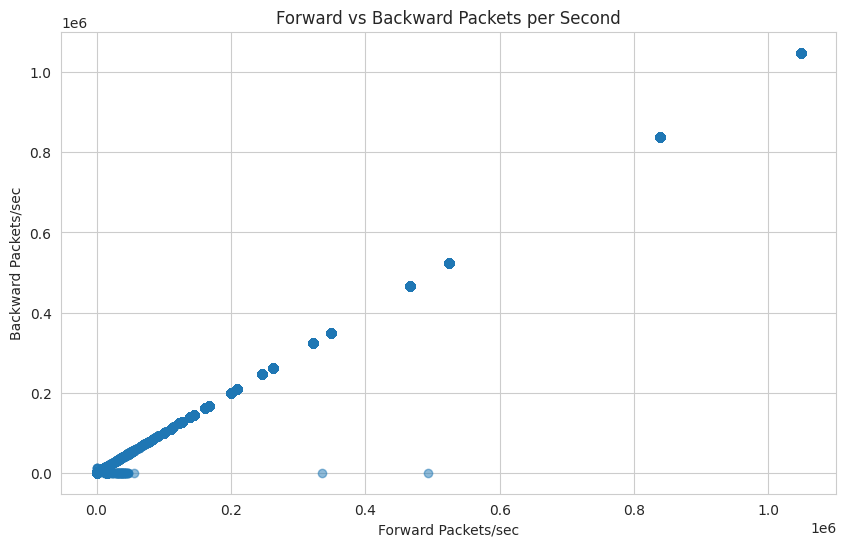


Analysis and Visualization Complete
Index(['no', 'id.orig_p', 'id.resp_p', 'proto', 'service', 'flow_duration',
       'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot',
       'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec',
       'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot',
       'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot',
       'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count',
       'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count',
       'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count',
       'bwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count',
       'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot',
       'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min',
       'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg',
       'bwd_pkts_payload.std', 'flow_pkts_payload.min',
       'flow_pkts_payl

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("RT_IOT2022.csv")

# Transform data
def transform_data(df):
    df.columns = df.columns.str.strip()  # remove possible spaces in column names

    if 'attack_type' in df.columns:
        df['Label_encoded'] = df['attack_type'].astype('category').cat.codes
    else:
        print("Column 'attack_type' not found.")

    # Convert selected columns to numeric if needed
    numeric_cols = ['flow_duration', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec']
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    return df


transformed_data = transform_data(data)

print("Transformed Dataset Sample")
print(transformed_data.head())


# Analyze data
def analyze_data(df):
    print("Starting Data Analysis")

    if df.empty:
        print("DataFrame is empty")
        return

    required_cols = ['flow_duration', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec']

    for col in required_cols:
        if col not in df.columns:
            print(f"Missing column: {col}")
            return

    print("\nStatistical Summary")
    print(df[required_cols].describe())

    print("\n--- Correlation Matrix ---")
    corr_cols = required_cols + ['Label_encoded']
    corr_cols = [c for c in corr_cols if c in df.columns]

    corr_matrix = df[corr_cols].corr()
    print(corr_matrix)

    sns.set_style("whitegrid")

    # 1 Histogram (Seaborn)
    plt.figure(figsize=(10,6))
    sns.histplot(df['flow_duration'], bins=50, kde=True)
    plt.title('Distribution of Flow Duration')
    plt.xlabel('Flow Duration')
    plt.ylabel('Frequency')
    plt.show()

    # 2 Boxplot (Seaborn)
    if 'Label_encoded' in df.columns:
        plt.figure(figsize=(12,7))
        sns.boxplot(x='Label_encoded', y='fwd_pkts_per_sec', data=df)
        plt.title('Forward Packets per Second by Attack Type')
        plt.xlabel('Attack Type (Encoded)')
        plt.ylabel('Forward Packets per Second')
        plt.show()

    # 3 Heatmap (Seaborn)
    plt.figure(figsize=(10,8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Heatmap')
    plt.show()

    # -------------------------
    # Additional Matplotlib Visualizations
    # -------------------------

    # 4 Scatter Plot (Matplotlib)
    plt.figure(figsize=(10,6))
    plt.scatter(df['fwd_pkts_per_sec'], df['bwd_pkts_per_sec'], alpha=0.5)
    plt.title("Forward vs Backward Packets per Second")
    plt.xlabel("Forward Packets/sec")
    plt.ylabel("Backward Packets/sec")
    plt.grid(True)
    plt.show()

    # 5 Bar Chart (Matplotlib)
    if 'attack_type' in df.columns:
        attack_counts = df['attack_type'].value_counts().head(10)

        plt.figure(figsize=(12,6))
        plt.bar(attack_counts.index, attack_counts.values)
        plt.title("Top 10 Attack Types")
        plt.xlabel("Attack Type")
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    print("\nAnalysis and Visualization Complete")
    print(df.columns)


# Run analysis
analyze_data(transformed_data)

**Summary/Analysis**

This document, "Midterm Quiz 2: Data Analysis using Pandas," outlines a three-phase process (Extract, Transform, Load) for analyzing an IoT dataset (RT_IOT2022.csv) using Python's Pandas, Seaborn, and Matplotlib libraries. The Extract phase involves importing necessary libraries, loading the CSV file into a Pandas DataFrame, and previewing the data. The Transform phase focuses on data cleaning and preparation, specifically standardizing column names, encoding categorical attack labels into numeric values, converting key features like packet rates and flow duration to a numeric format, generating a statistical summary, and computing a feature correlation matrix. Finally, the Load phase visualizes the processed data through a histogram of flow duration, a boxplot of forward packets per second by attack type, a correlation heatmap for selected features, and a scatter plot illustrating the relationship between forward and backward packet rates.